# Can you get rich shorting diamonds? 💎
### "Lab-grown is killing the natural diamond" — a real collapse, tested as a trade

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Diamonds_collapsing%3F: Confirmed](https://img.shields.io/badge/Diamonds_collapsing%3F-Confirmed-8b949e?style=flat-square)

You've seen the headlines: lab-grown diamonds are chemically identical, cost a fraction, and their wholesale price has **collapsed ~80–90%**. Natural-diamond prices peaked in early 2022 and have been sliding ever since. So the pitch writes itself: *"the diamond is dying — **short the diamond**, short the miners, or buy the beaten-down miner for the rebound."* De Beers is cutting prices; the whole complex looks like a falling knife you could profit from.

This notebook does something the pitch never does: it asks whether you could actually **make money** on the collapse. We line the (cited, approximate) natural-diamond price index up next to the S&P 500, then look at the only things you can really trade — the jeweler **Signet** and a pure-play **diamond miner** — and charge the frictions (borrow, spreads) the pitch forgets.

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West alpha and the borrow algebra? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** Real polished-diamond price indices (Rapaport RAPI, IDEX, Zimnisky) aren't free to pull, so the price line below is a **small, clearly-cited, approximate** reconstruction of public reporting — a **proxy**, never presented as the live index. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from diamond_price_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_price_index()                        # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| price-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2018 → 2025', 'idx_levels': {2018: 100, 2019: 94, 2020: 96, 2021: 118, 2022: 122, 2023: 104, 2024: 92, 2025: 90}, 'idx_yoy': {2019: -6.0, 2020: 2.1, 2021: 22.9, 2022: 3.4, 2023: -14.8, 2024: -11.5, 2025: -2.2}, 'peak_date': '2022-02', 'peak_level': 132, 'peak_trough': -31.8, 'idx_cagr': -1.49, 'idx_vol': 12.4, 'idx_sharpe': -0.07, 'idx_mdd': -26.2, 'spy_cagr_ye': 17.18, 'spy_vol_ye': 16.9, 'spy_mdd_ye': -18.2, 'excess_mean': -19.27, 'excess_t': -2.302, 'excess_p': 0.061, 'excess_n': 7, 'sig_cagr': 17.05, 'sig_vol': 66.2, 'sig_sharpe': 0.61, 'sig_mdd': -77.8, 'sig_alpha': 7.32, 'sig_beta': 1.91, 'sig_t': 0.32, 'sig_p': 0.753, 'sig_n': 84, 'luc_cagr': -24.27, 'luc_vol': 49.6, 'luc_sharpe': -0.32, 'luc_mdd': -88.8, 'luc_alpha': -26.0, 'luc_beta': 0.82, 'luc_t': -1.73, 'luc_p': 0.087, 'luc_n': 84, 'luc_total': -85.7, 'spy_cagr': 17.18, 'spy_vol': 16.6, 'spy_sharpe': 1.04, 'spy_mdd': -23.9, 'short_cagr': -22.59, 'short_vol': 49.6, 'short_sharpe': -0.22, 'short_mdd': -93.5, 'short_borrow': 30, 'short_nb_cagr': 1.91, 'short_nb_total': 13.9, 'haircut_gross': -1.49, 'haircut_spread': -14.76, 'haircut_insure': -0.5, 'haircut_net': -16.45, 'syn_peak': 201, 'syn_end': 86, 'syn_back_cagr': -17.01, 'syn_sharpe': -0.08, 'syn_mdd': -58.6}


equity-proxy cache present: True | price-index years: 2018 -> 2025


## The answer first

| Question | Answer |
|---|---|
| Are natural-diamond prices really collapsing? | **Yes.** The index peaked near **2022-02** and round-tripped **-32%** to a lower level by 2025, as lab-grown wholesale prices fell ~80–90%. The collapse is **real**. |
| So can you short it? | **Not really.** There's no diamond future. Shorting the miner means borrowing a **-86%** penny-stock — and after the borrow fee that short **loses 23%/yr** anyway. |
| Buy the beaten-down miner for a rebound? | **No rebound.** The pure-play miner kept falling — down **-86%** over the window, a **-89%** drawdown. A value trap, not a bounce. |
| Is a diamond at least a store of value? | **The opposite.** Buy retail, sell near wholesale: the physical stone's return is **~-16%/yr** net of the resale haircut. A diamond is a spending decision, not an asset. |

> The diagnosis is dead right — diamonds *are* collapsing. But being right about the collapse and getting **paid** for it are two very different things. The S&P beat every leg.

## 1 · The claim

> *"Lab-grown diamonds are chemically identical and cost 90% less. They will destroy the natural-diamond business — prices are already falling and De Beers is slashing. Short the diamond complex, short the miners, and you'll ride the whole thing down. Or wait for capitulation and buy a miner for cents on the dollar."*

It's a *steelman-able* claim, and the first half is simply **true**: lab-grown grew from a novelty to a huge share of the engagement market in a few years, its wholesale price cratered ~80–90%, and natural polished prices (Rapaport's 1ct RAPI, the IDEX index) fell roughly **-18% in 2023** and **-11% in 2024** off an early-2022 peak. De Beers cut rough prices repeatedly. The *diagnosis* is one of the best-supported bearish stories in luxury.

## 2 · So what?

If a real, obvious, multi-year price collapse could be turned into a trade, it would be a money machine — a slow-motion short with a known catalyst. That's exactly why the pitch is seductive. But *"prices are falling"* and *"you can profit from prices falling"* are different statements. A diamond isn't a stock you can short; the listed proxies are a jeweler and a handful of tiny miners, each with its own story; and shorting anything costs **borrow**. Between the diagnosis and the P&L sits a wall of microstructure — and that's where we look.

## 3 · How would we even know?

Three honest comparisons, each against the S&P 500 (SPY):

1. **The price index vs SPY.** Put the (cited, approximate) natural-diamond price index next to SPY on the same 2018–2025 clock — did diamonds hold value, or fall?
2. **The things you can actually trade.** You can't short "the diamond." You *can* trade **Signet** (the big US diamond jeweler) and **Lucara** (a pure-play miner). Long or short, do they hand you a *diamond* edge — or just idiosyncratic stock risk?
3. **The cost of the trade.** Shorting a penny-stock miner pays a fat borrow fee; owning a physical diamond pays a brutal retail→resale spread. Charge those, and see what's left.

**What would make us say "tradable edge"?** A listed leg that clears a real *t* ≥ 2 in the trade's favour **and** survives borrow/spread. Anything less is a correct diagnosis with no P&L attached.

## 4 · The teardown — let's actually look

**First: the collapse is real.** Here is the (approximate, cited) natural-diamond price index — the boom into 2022 and the slide since.

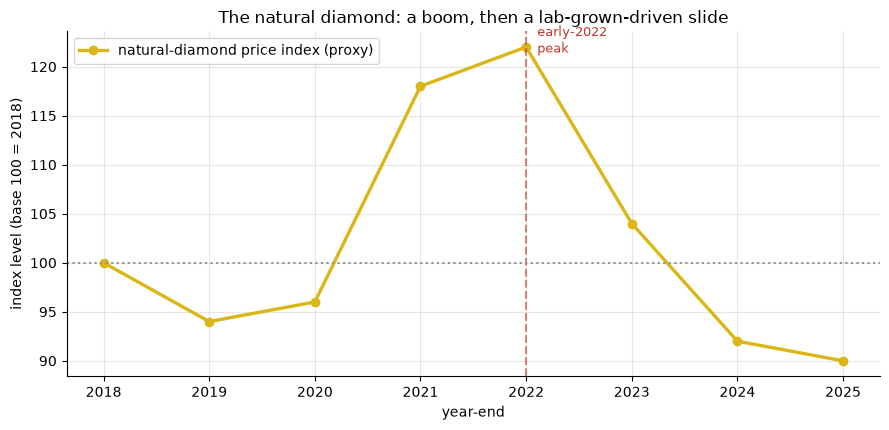

levels: {2018: 100, 2019: 94, 2020: 96, 2021: 118, 2022: 122, 2023: 104, 2024: 92, 2025: 90}
down -32% from the early-2022 peak to the 2025 level


In [2]:
yrs = list(R['idx_levels'].keys())
lv = [float(IDX.loc[f'{y}-12-31']) for y in yrs]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.4, label='natural-diamond price index (proxy)')
ax.axvline(2022, ls='--', c=RED, alpha=.6)
ax.annotate('early-2022\npeak', (2022, max(lv)), textcoords='offset points',
            xytext=(8, -4), color=RED, fontsize=9)
ax.axhline(100, ls=':', c=GREY)
ax.set_xlabel('year-end'); ax.set_ylabel('index level (base 100 = 2018)')
ax.set_title('The natural diamond: a boom, then a lab-grown-driven slide'); ax.legend()
plt.tight_layout(); plt.show()
print('levels:', {y:int(round(v)) for y,v in zip(yrs, lv)})
print(f"down {R['peak_trough']:.0f}% from the early-2022 peak to the 2025 level")

The slide is real: **-32%** off the early-2022 top, and still drifting lower in 2025. Lab-grown really is eating the natural stone's lunch. So far the bear pitch looks completely right — which is exactly why the next three charts matter.

**But is a diamond a store of value?** Same money, same years — the price index vs the S&P.

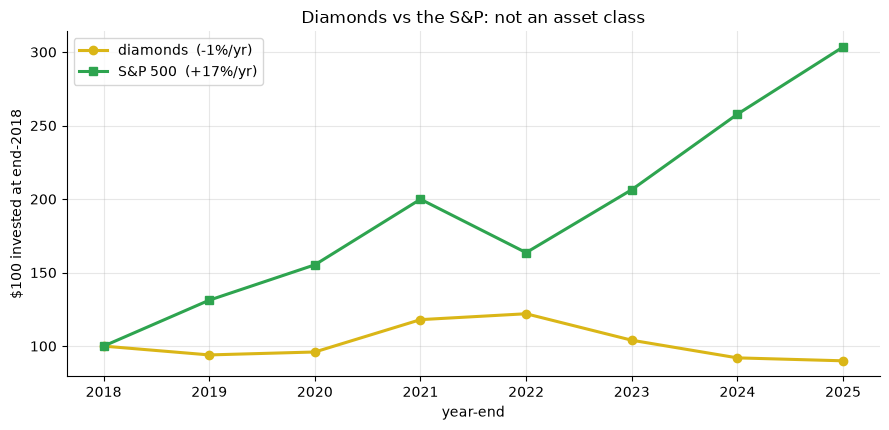

diamonds CAGR ~-1.5%  vs  SPY CAGR ~17.2%  |  diamonds maxDD -26%  vs  SPY -18%


In [3]:
if HAVE_PROXIES:
    spy = PROX['SPY']; spy_ye = spy.resample('YE').last()
    spy_ye = spy_ye[(spy_ye.index.year>=2018)&(spy_ye.index.year<=2025)]
    spy_norm = spy_ye/spy_ye.iloc[0]*100
    sx = [d.year for d in spy_norm.index]; sy = list(spy_norm.values)
else:
    sx, sy = yrs, [100*(1+R['spy_cagr_ye']/100)**(y-2018) for y in yrs]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.2, label=f"diamonds  ({R['idx_cagr']:+.0f}%/yr)")
ax.plot(sx, sy, 's-', c=GREEN, lw=2.2, label=f"S&P 500  ({R['spy_cagr_ye']:+.0f}%/yr)")
ax.set_xlabel('year-end'); ax.set_ylabel('$100 invested at end-2018')
ax.set_title('Diamonds vs the S&P: not an asset class'); ax.legend()
plt.tight_layout(); plt.show()
print(f"diamonds CAGR ~{R['idx_cagr']:.1f}%  vs  SPY CAGR ~{R['spy_cagr_ye']:.1f}%  |  "
      f"diamonds maxDD {R['idx_mdd']:.0f}%  vs  SPY {R['spy_mdd_ye']:.0f}%")

As an *asset*, the diamond was a disaster: **-1.5%/yr** while the S&P compounded **+17.2%/yr**. That confirms the diagnosis — but it also kills the mirror-image dream ("diamonds as a hedge / store of value"). The interesting question is the *other* side: if diamonds fell, can you get **paid** to be short?

**"Fine — I'll short the miner / buy the miner."** Meet the two things you can actually trade: Signet (the jeweler) and Lucara (a pure-play miner). Here's how they did.

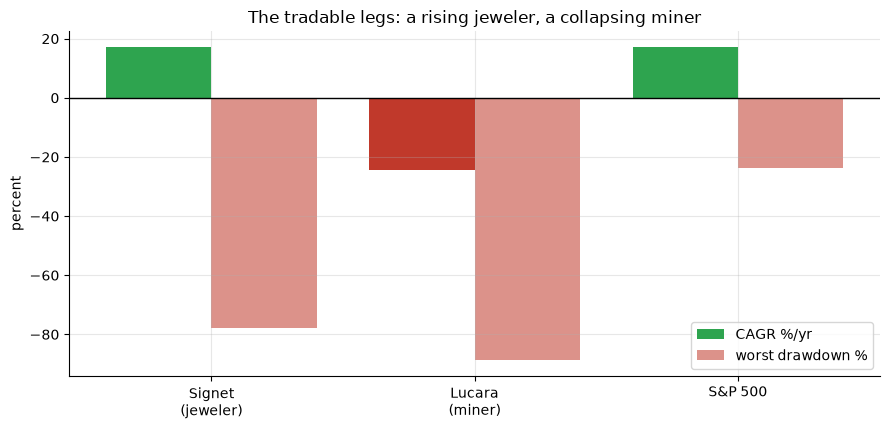

SIG:    CAGR +17.1%/yr but maxDD -78% (beta 1.9)
LUC.TO: CAGR -24.3%/yr, total -86%, maxDD -89%


In [4]:
names = ['Signet\n(jeweler)', 'Lucara\n(miner)', 'S&P 500']
cagrs = [R['sig_cagr'], R['luc_cagr'], R['spy_cagr']]
mdds  = [R['sig_mdd'], R['luc_mdd'], R['spy_mdd']]
x = np.arange(3); fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(x-.2, cagrs, .4, color=[GREEN if c>=0 else RED for c in cagrs], label='CAGR %/yr')
ax.bar(x+.2, mdds, .4, color=RED, alpha=.55, label='worst drawdown %')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('percent'); ax.set_title('The tradable legs: a rising jeweler, a collapsing miner'); ax.legend()
plt.tight_layout(); plt.show()
print(f"SIG:    CAGR {R['sig_cagr']:+.1f}%/yr but maxDD {R['sig_mdd']:.0f}% (beta {R['sig_beta']:.1f})")
print(f"LUC.TO: CAGR {R['luc_cagr']:+.1f}%/yr, total {R['luc_total']:.0f}%, maxDD {R['luc_mdd']:.0f}%")

Notice the split: the **jeweler rose** (+17%/yr — jewelers happily sell lab-grown too) while the **miner collapsed** (-86%). "Short the diamond" would mean shorting the miner — and directionally, you'd have been right. So did the short print money?

**Here's the trap. It costs money to be short.** A tiny, cratering miner is *hard to borrow* — call it ~30%/yr. Worse, a falling penny-stock is wildly volatile: it had **+40%-plus up-months** that gut a short. Let's build the short book honestly.

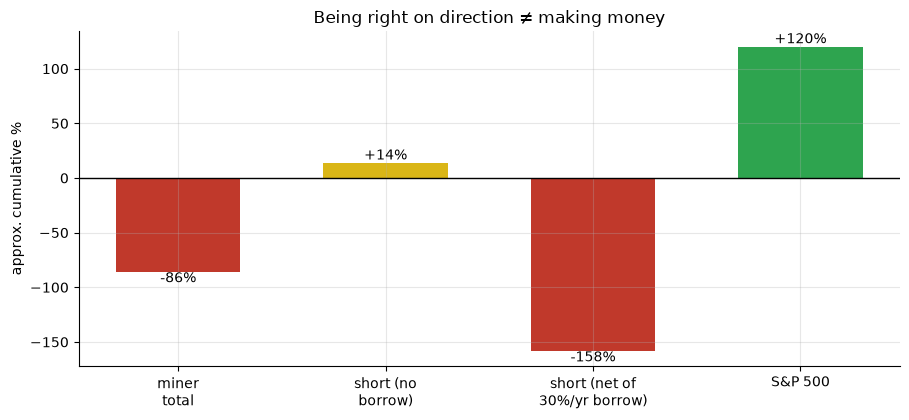

miner fell -86%, yet a short book made only ~+14% GROSS
net of 30%/yr borrow the short book LOSES ~-23%/yr


In [5]:
labels = ['miner\ntotal', 'short (no\nborrow)', 'short (net of\n30%/yr borrow)', 'S&P 500']
vals = [R['luc_total'], R['short_nb_total'], R['short_cagr']*7, R['spy_cagr']*7]
# express as total-ish % over the ~7y window for a like-for-like eyeball
cols = [RED, AMBER, RED, GREEN]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('approx. cumulative %')
for i,v in enumerate(vals): ax.annotate(f'{v:+.0f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('Being right on direction ≠ making money')
plt.tight_layout(); plt.show()
print(f"miner fell {R['luc_total']:.0f}%, yet a short book made only ~{R['short_nb_total']:+.0f}% GROSS")
print(f"net of 30%/yr borrow the short book LOSES ~{R['short_cagr']:+.0f}%/yr")

There it is. The miner **fell -86%**, yet the short book netted only **~+14% gross** over seven years — because those +40% up-months wreck a short (volatility drag). Then the **borrow fee** turns the whole thing **negative (-23%/yr)**. You called the collapse perfectly and still lost.

**And the physical stone?** The "diamonds are forever / a store of value" side never charges the ugliest fact: you buy at **retail** and sell near **wholesale**. Charge that resale haircut on the index's gross return:

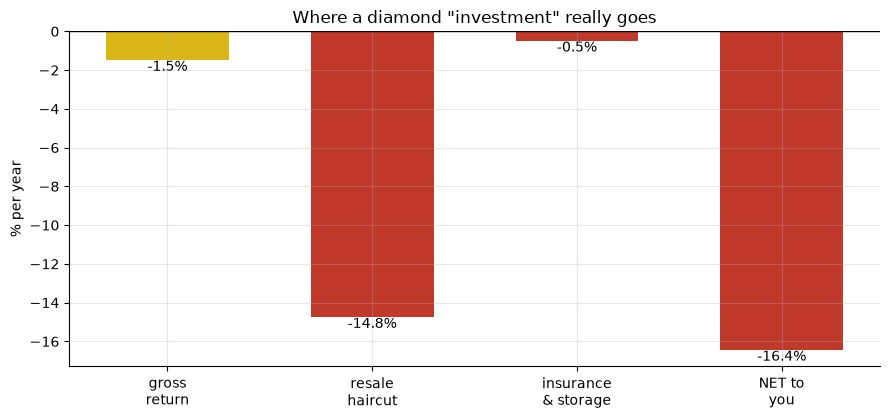

gross -1.5%/yr  ->  NET -16.4%/yr after resale spread + carry


In [6]:
labels = ['gross\nreturn', 'resale\nhaircut', 'insurance\n& storage', 'NET to\nyou']
vals = [R['haircut_gross'], R['haircut_spread'], R['haircut_insure'], R['haircut_net']]
cols = [AMBER, RED, RED, RED]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('% per year')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('Where a diamond "investment" really goes')
plt.tight_layout(); plt.show()
print(f"gross {R['haircut_gross']:+.1f}%/yr  ->  NET {R['haircut_net']:+.1f}%/yr after resale spread + carry")

A gross **-1.5%/yr** that already lost to the S&P becomes **~-16%/yr** once you pay to buy-retail-sell-wholesale and insure the stone. A diamond is a purchase, not a position.

## 5 · The verdict

- **Signal — None.** No listed leg gives you a harvestable *diamond* edge: the jeweler is high-beta beta (+17%/yr, alpha *t*=+0.32), the miner is idiosyncratic single-mine risk (alpha *t*=-1.73), and the short book loses net of borrow.
- **Tradability — Mirage.** No diamond future; the short pays a fat borrow and gets eaten by volatility drag; the physical stone's resale haircut is brutal. Nothing scales.
- **Diamonds collapsing? — Confirmed.** The one thing that *is* true: natural-diamond prices really did collapse as lab-grown scaled. The diagnosis is right; the trade is not there.

## 6 · Could you actually trade it? — the honest bottom line

Imagine four people at the end of 2018, each with \$10,000. One buys an S&P index fund. One shorts the diamond miner (paying borrow). One buys the miner for the "rebound." One buys a physical diamond as a "store of value." Where do they land by end-2025?

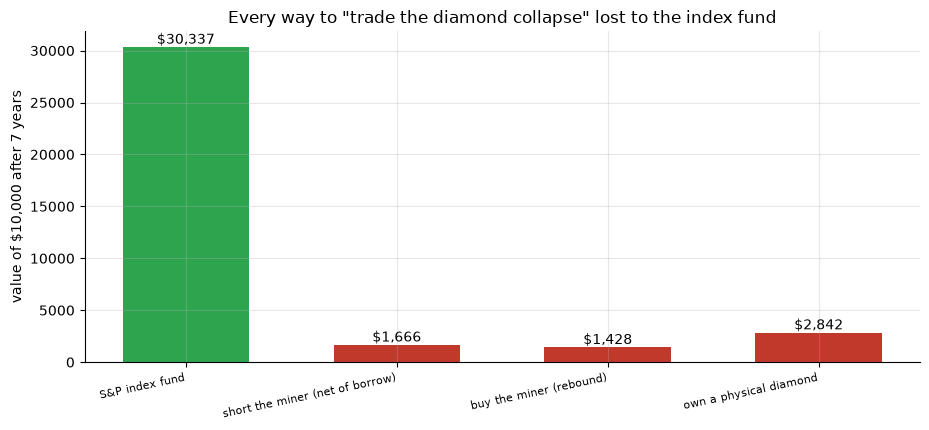

S&P index fund                     $    30,337  (+17.2%/yr)
short the miner (net of borrow)    $     1,666  (-22.6%/yr)
buy the miner (rebound)            $     1,428  (-24.3%/yr)
own a physical diamond             $     2,842  (-16.4%/yr)


In [7]:
start=10_000.0; yrs_h=7
paths={'S&P index fund':R['spy_cagr']/100, 'short the miner (net of borrow)':R['short_cagr']/100,
       'buy the miner (rebound)':R['luc_cagr']/100, 'own a physical diamond':R['haircut_net']/100}
fig, ax = plt.subplots(figsize=(9.4,4.4))
labels=list(paths); ends=[start*(1+g)**yrs_h for g in paths.values()]
cols=[GREEN, RED, RED, RED]
ax.bar(range(len(labels)), ends, .6, color=cols)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=8)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 7 years'); ax.set_title('Every way to "trade the diamond collapse" lost to the index fund')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l:34s} ${start*(1+g)**yrs_h:>10,.0f}  ({g*100:+.1f}%/yr)")

The index-fund investor roughly **triples** their money doing nothing. Every single diamond-collapse expression — the short, the contrarian long, the physical stone — ends up **worth less than the stake**. The collapse was real and obvious, and it still couldn't be turned into a dollar. That's the whole lesson.

## 7 · Going further 🚪

- **Pull the real index yourself.** Our price line is a cited *approximation*; Rapaport / IDEX / Zimnisky publish the live series (paywalled). Swap it in — the shape (and the verdict) won't move.
- **Try a cleaner short.** Anglo American (De Beers' parent) or a basket of miners instead of one penny-stock — but you'll dilute the "diamond" exposure into diversified mining beta, and the borrow/vol problem doesn't vanish.
- **The collapsing-commodity pattern.** Real, obvious, multi-year price declines that still aren't tradable are everywhere — see [docs/references.md](../docs/references.md).

*Think there's a clean way to be paid for the diamond collapse — a specific miner, a specific hedge? Pull its history, charge the borrow and the spread, and show it beats the index fund. That's the bar.*